In [12]:
import networkx as nx
import itertools

import matplotlib.pyplot as plt
%matplotlib inline 

def draw_simplices(synapses, cell_type ,pos=None, return_pos=False, ax = None):
    """
    Draw simplices from a list of synaptic configurations.
    
    Adapted from https://github.com/iaciac/py-draw-simplicial-complex/blob/master/Draw%202d%20simplicial%20complex.ipynb    
    
        Args
        ----
        synapses: list of lists
        
        A tripartite synapse is represented by a list with three integers [1,2,3] to draw a 2-simplex, then automatically decomposed 
        to 1-simplices [1,2], [2,3], and [1,3] where 1, and 3 are neurons and 2 is an astrocyte. The integers that represent cells are the 0-simplices.  
        
        One-one-directed synapses are represented by a list with just one list with two integers (e.g. [[1,3]] means neuron 1 synapse into neuron 3). 
        
        Symmetric synaptic configuration are represented as a list of list of integeres [[1,2],[2,1]].    

        cell_type: list of strings 
        
        "A" for an astrocyte
        "N" for a neuron 

        example: [A,N,A] means cells with index 0 and 2 are astrocytes and the cell with index 1 is a neuron. 
        
        pos: dict (default=None)
            If passed, this dictionary of positions d:(x,y) is used for placing the 0-simplices.
            The standard nx spring layour is used otherwise.
           
        ax: matplotlib.pyplot.axes (default=None)
        
        return_pos: dict (default=False)
            If True returns the dictionary of positions for the 0-simplices.
            
        References
        ----------    
        .. [1] I. Iacopini, G. Petri, A. Barrat & V. Latora (2019)
               "Simplicial Models of Social Contagion".
               Nature communications, 10(1), 2485.
    """

    
    #List of 0-simplices
    nodes_raw = [j for i in synapses for j in i]
    #nodes =list(set(itertools.chain(*nodes)))
    nodes_iterables = [j if isinstance(j, (list, tuple, set)) else [j] for j in nodes_raw]
    nodes = list(set(itertools.chain.from_iterable(nodes_iterables)))

    #List of arcs
    arcs = []
    arcs_color = []
    for i in synapses:
        if len(i) == 3:
            arcs += [[i[0],i[1]],[i[1],i[2]],[i[0],i[2]]]
            arcs_color += ['firebrick','firebrick','black']
        else:
            arcs += i
            arcs_color.append ('black')
    
    #List of tripartites
    tripartite = [i for i in synapses if len(i) == 3 ]
    
    if ax is None: ax = plt.gca()
    ax.set_xlim([-1.1, 1.1])      
    ax.set_ylim([-1.1, 1.1])
    ax.get_xaxis().set_ticks([])  
    ax.get_yaxis().set_ticks([])
    ax.axis('off')
       
    if pos is None:
        # Creating a networkx Graph from the edgelist
        G = nx.Graph()
        G.add_edges_from(arcs)
        # Creating a dictionary for the position of the nodes
        pos = nx.spring_layout(G)
        
    # Drawing the edges
    arc_number = 0
    for i, j in arcs:
        ax.annotate("", xytext=pos[i], xy=pos[j],
                    arrowprops=dict(facecolor= arcs_color[arc_number],edgecolor = arcs_color[arc_number], width = 0.2, headwidth= 6, shrink = 0.07));
        arc_number +=  1
    
    # Filling in the triangles
    num_tripartite = 0
    past_xy_lab = []
    for i, j, k in tripartite:
        num_tripartite +=1 
        (x0, y0) = pos[i]
        (x1, y1) = pos[j]
        (x2, y2) = pos[k]
        x = round((x0 + x1 + x2) / 3, 2)
        y = round((y0 + y1 + y2) / 3, 2)
        tri = plt.Polygon([ [ x0, y0 ], [ x1, y1 ], [ x2, y2 ] ],
                          edgecolor = 'black', facecolor = plt.cm.Blues(0.6),
                          zorder = 2, alpha=0.4, lw=0.5)
        ax.add_patch(tri);
        if (x,y) not in  past_xy_lab:
            label = ax.annotate(str(num_tripartite), xy=(x,y), fontsize=20, verticalalignment="center",
                            horizontalalignment="center", c = 'gray' )
        else: 
            label = ax.annotate(str(num_tripartite), xy=(x+0.4,y+0.4), fontsize=20, verticalalignment="center",
                            horizontalalignment="center", c = 'gray' )
        past_xy_lab.append ((x,y))
    # Drawing the nodes
    edge_color_list = ['black'if i == 'N' else 'r' for i in cell_type]
    label_numbers = []
    neurons_number = 0
    astrocyte_number = 0
    for i in cell_type:
        if i == 'N':
            neurons_number +=1
            label_numbers.append (neurons_number)
        elif i == 'A':
            astrocyte_number +=1
            label_numbers.append (astrocyte_number)
    for i in nodes:
        (x, y) = pos[i]
        circ = plt.Circle([ x, y ], radius = 0.1, zorder = 3, lw=0.5,
                          edgecolor = edge_color_list[i-1], facecolor = 'w' )
        ax.add_patch(circ);
        label = ax.annotate(r'$' + cell_type[i-1] + '_'+str(label_numbers[i-1]) + '$', xy=(x, y), fontsize=13, verticalalignment="center",
         horizontalalignment="center", c = edge_color_list[i-1] )
    if return_pos: return pos

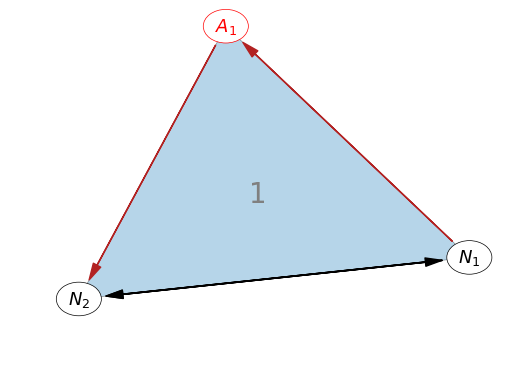

In [35]:
#Figure 4a 
draw_simplices([[[1,3]],[[3,1]],[1,2,3]],['N','A','N'])

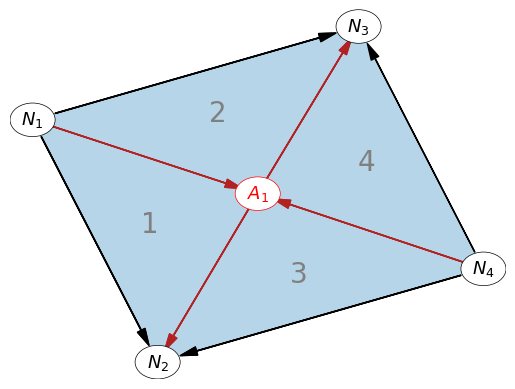

In [33]:
#Figure 4b
draw_simplices([[1,2,3],[[1,3]],[1,2,4],[5,2,3],[[1,4]],[[5,3]],[5,2,4]],['N','A','N','N','N'])

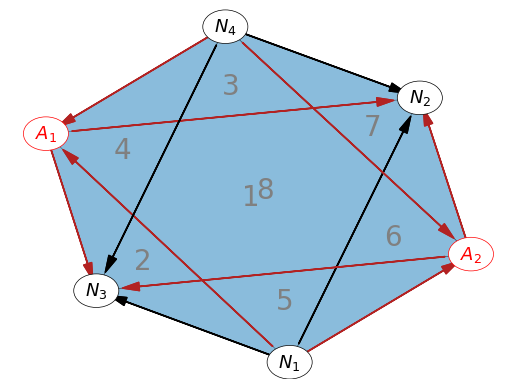

In [42]:
#Figure 4c
draw_simplices([[1,2,3],[1,2,4],[5,2,3],[5,2,4],[1,6,4],[1,6,3],[5,6,3],[5,6,4]],['N','A','N','N','N','A'])

In [40]:
#draw_simplices([[[1,2]],[[2,1]],[1,2,3],[3,2,1]],['N','A','N'])